<a href="https://colab.research.google.com/github/mgb1112/Data-Science-For-Public-Health/blob/main/hw10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Group Members: Cassie Chou, Jady Li, Kate Brown, Grace Brooks, Md Zakiul Alam**

# **Homework 10**

A virus is coming where 50% of the cryptopunks will have contracted a disease where they get a white spot. The code below generates the disease. Your job is as follows

1. Generate the data as below
2. Train a convolutional neural network to classify punks as diseased or not
  1. Create training and validation sets.
  2. Contrast in the sensitivity, specificity and accuracy in both sets.
The code below shows you how to generate the data for this assignment. (Task #1.)

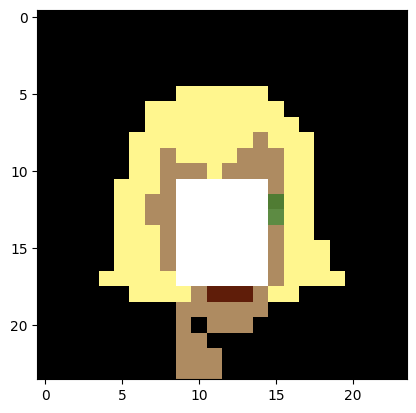

In [ ]:
# generate the data for the assignment (given code)
import urllib.request
import PIL
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, losses

## open the image
imgURL = "https://raw.githubusercontent.com/larvalabs/cryptopunks/master/punks.png"
urllib.request.urlretrieve(imgURL, "cryptoPunksAll.jpg")
img = PIL.Image.open("cryptoPunksAll.jpg").convert("RGB")
imgArray = np.asarray(img)

n = 10000

finalArray = np.empty((n, 24, 24, 3))
for i in range(100):
  for j in range(100):
    a, b = 24 * i, 24 * (i + 1)
    c, d = 24 * j, 24 * (j + 1)
    idx = j + i * (100)
    finalArray[idx,:,:,:] = imgArray[a:b,c:d,:]

# region where the tumor occurs
temp  =  finalArray[0,:,:,:].copy()
d2min, d2max = 9,14
d1min, d1max = 11,17
temp[d1min : (d1max + 1), d2min : (d2max + 1)] = 255
plt.imshow(temp.astype('uint8'));

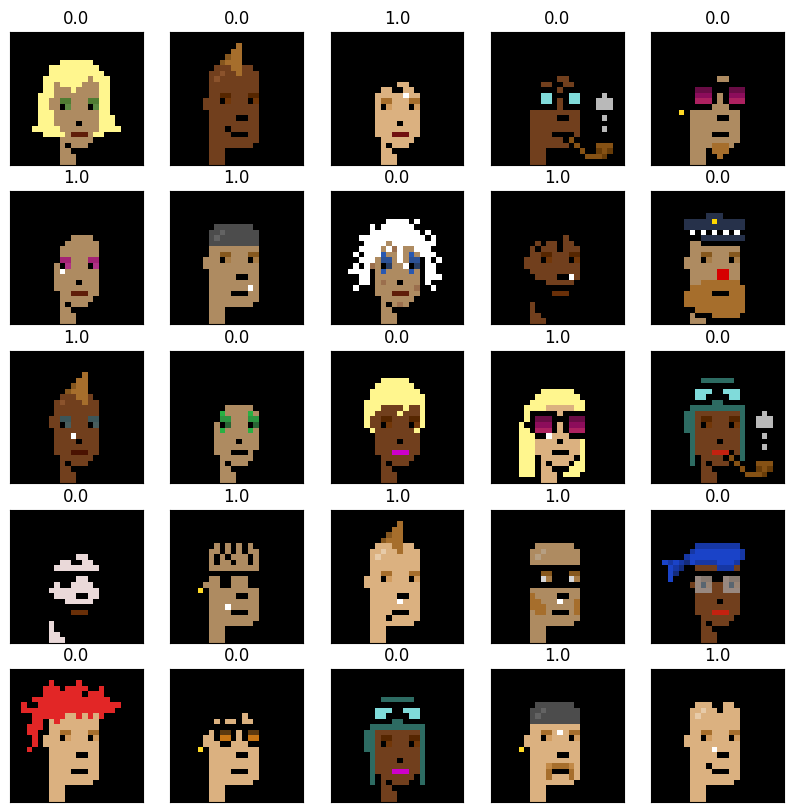

In [ ]:
# examples of images with the tumor (given code)
cancerpunks = finalArray.copy()
label = np.zeros(n)

## Loop over the cryptopunks
for i in range(10000):
  flip = np.random.randint(0, 2)
  if flip == 1:
    label[i] = 1
    d1loc = np.random.randint(d1min, d1max + 1)
    d2loc = np.random.randint(d2min, d2max + 1)
    cancerpunks[i,d1loc,d2loc,:] = 255

plt.figure(figsize=(10,10))
for i in range(25):
  plt.subplot(5,5,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(cancerpunks[i,:,:,:].astype('uint8'))
  plt.title(label[i])

In [ ]:
# create training and validation sets
trainFraction = 0.6
sample = np.random.uniform(size = n) < trainFraction
x_train = cancerpunks[sample, :, :, :] / 255
y_train = label[sample]

x_test = cancerpunks[~sample, :, :, :] / 255
y_test = label[~sample]

## Need to have the extra dimension
y_train = y_train.reshape(y_train.shape[0], 1)
y_test = y_test.reshape(y_test.shape[0], 1)


# Split to Validation Set
valFraction = 0.5
sample2 = np.random.uniform(size = len(x_test)) < valFraction
x_val = x_test[sample2, :, :, :]
y_val = y_test[sample2, ]

x_test = x_test[~sample2, :, :, :]
y_test = y_test[~sample2, ]

print([x_train.shape, x_test.shape, x_val.shape])
print([y_train.shape, y_test.shape, y_val.shape])



[(6006, 24, 24, 3), (1996, 24, 24, 3), (1998, 24, 24, 3)]
[(6006, 1), (1996, 1), (1998, 1)]


In [ ]:
# 4) DEFINE A SMALL CNN
punk_size = 24
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(punk_size, punk_size, 3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 5) TRAIN
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(x_val, y_val)
)

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.4928 - loss: 0.6965 - val_accuracy: 0.5921 - val_loss: 0.6833
Epoch 2/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.6320 - loss: 0.6572 - val_accuracy: 0.7708 - val_loss: 0.4990
Epoch 3/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.8573 - loss: 0.3772 - val_accuracy: 0.9049 - val_loss: 0.2563
Epoch 4/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.9140 - loss: 0.2188 - val_accuracy: 0.9334 - val_loss: 0.1514
Epoch 5/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - accuracy: 0.9460 - loss: 0.1301 - val_accuracy: 0.9439 - val_loss: 0.1295
Epoch 6/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.9583 - loss: 0.0987 - val_accuracy: 0.9570 - val_loss: 0.0986
Epoch 7/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.9630 - loss: 0.0896 - val_accuracy: 0.9605 - val_loss: 0.0924
Epoch 8/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.9722 - loss: 0.0685 - val_accuracy: 0.9640 - val_loss: 0.

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


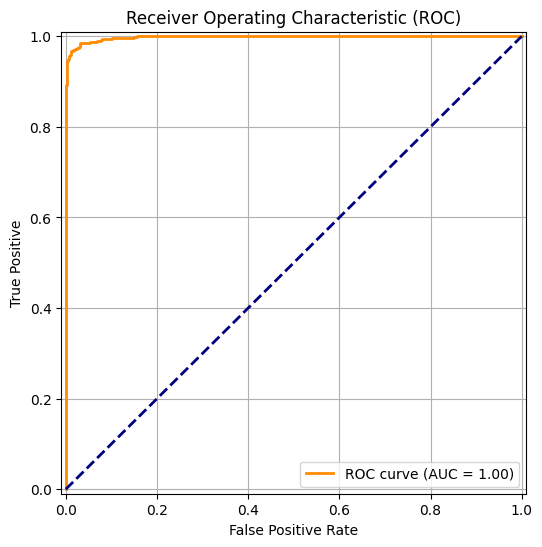

In [ ]:
# Get model predictions as probabilities
testout = model.predict(x_test)

# Use sklearn's ROC functions
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, testout)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix

# Define the evaluation function
def evaluate_performance(model, X, y):
    # Get model predictions, applying a threshold of 0.5 for classification
    y_pred = model.predict(X) > 0.5

    # Compute confusion matrix
    cm = confusion_matrix(y, y_pred)

    # Extract True Positives, False Positives, False Negatives, True Negatives
    tn, fp, fn, tp = cm.ravel()

    # Calculate accuracy, sensitivity, and specificity
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    sensitivity = tp / (tp + fn)  # True Positive Rate
    specificity = tn / (tn + fp)  # True Negative Rate

    return {
        "accuracy": accuracy,
        "sensitivity": sensitivity,
        "specificity": specificity
    }

# Evaluate on training set
train_metrics = evaluate_performance(model, x_train, y_train)

# Evaluate on validation set
val_metrics = evaluate_performance(model, x_test, y_test)

# Print the metrics
print("Train Metrics:", train_metrics)
print("Validation Metrics:", val_metrics)

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Train Metrics: {'accuracy': np.float64(0.9831834831834831), 'sensitivity': np.float64(0.9679550710274198), 'specificity': np.float64(0.9986572675394427)}
Validation Metrics: {'accuracy': np.float64(0.970440881763527), 'sensitivity': np.float64(0.9455984174085065), 'specificity': np.float64(0.9959390862944163)}


<ipython-input-33-265e4568e2d3>:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(f"Label: {int(y_train[i])}")  # Show the corresponding label (0 or 1)


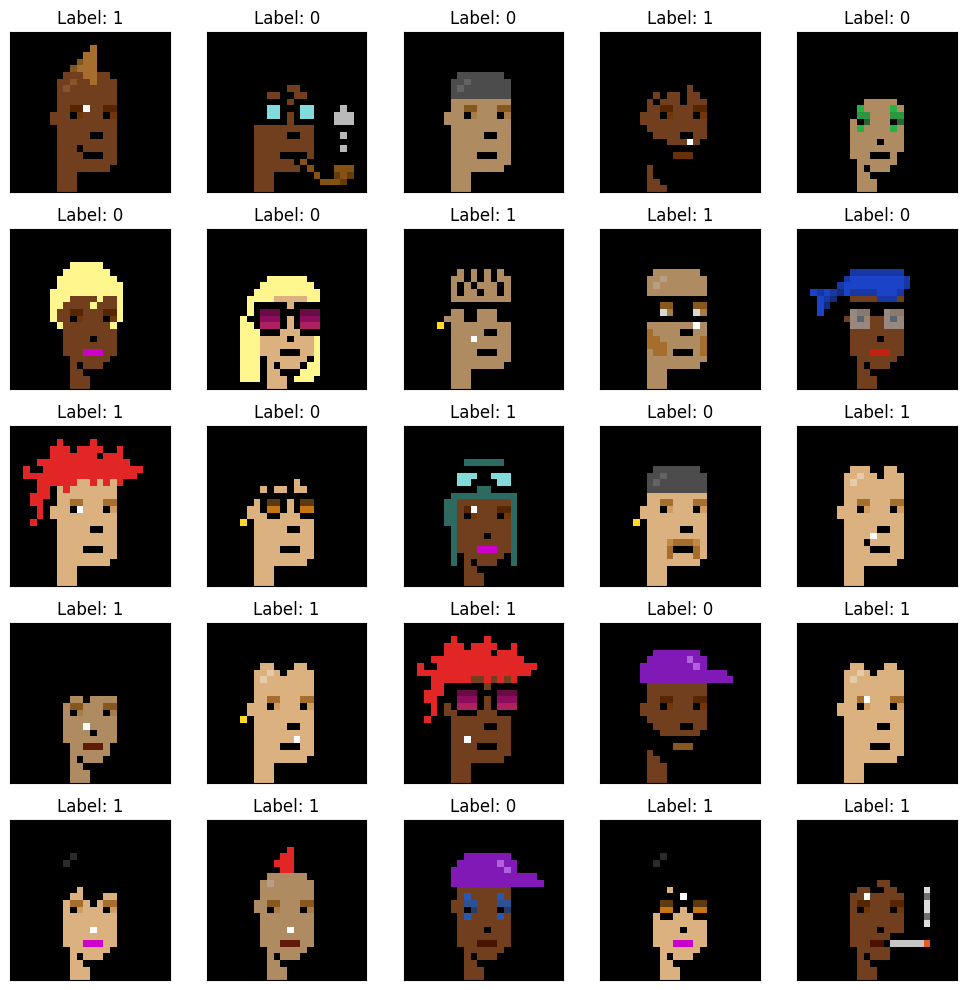

In [ ]:
##Visualiation of traning set
import matplotlib.pyplot as plt

# Visualize the first 25 images in the test set
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)  # 5x5 grid of subplots
    plt.xticks([])  # Remove x-axis ticks
    plt.yticks([])  # Remove y-axis ticks
    plt.imshow(x_train[i])  # Display the image from the test set
    plt.title(f"Label: {int(y_train[i])}")  # Show the corresponding label (0 or 1)

plt.tight_layout()
plt.show()


<ipython-input-17-dcbaba82bc02>:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(f"Label: {int(y_test[i])}")  # Show the corresponding label (0 or 1)


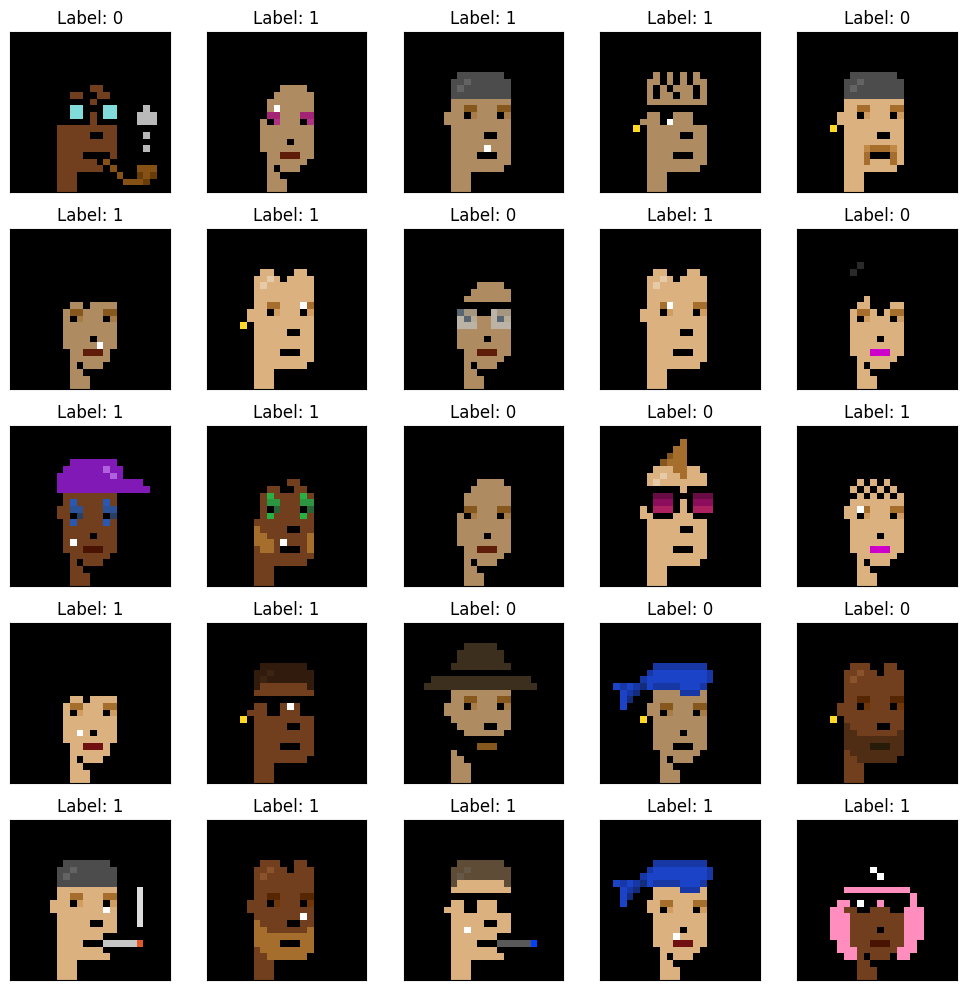

In [ ]:
##Visualiation of test set
import matplotlib.pyplot as plt

# Visualize the first 25 images in the test set
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)  # 5x5 grid of subplots
    plt.xticks([])  # Remove x-axis ticks
    plt.yticks([])  # Remove y-axis ticks
    plt.imshow(x_test[i])  # Display the image from the test set
    plt.title(f"Label: {int(y_test[i])}")  # Show the corresponding label (0 or 1)

plt.tight_layout()
plt.show()
